In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('D:\\AI_Pioneers_INternship\\diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
#Step 2: INspect Data Structure and check missing values

df.info() #Prints concise summary including count of non-null entrie
#Data type of each column

print(df.isnull().sum())  #Return the number of missing vlaues per columns

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome    

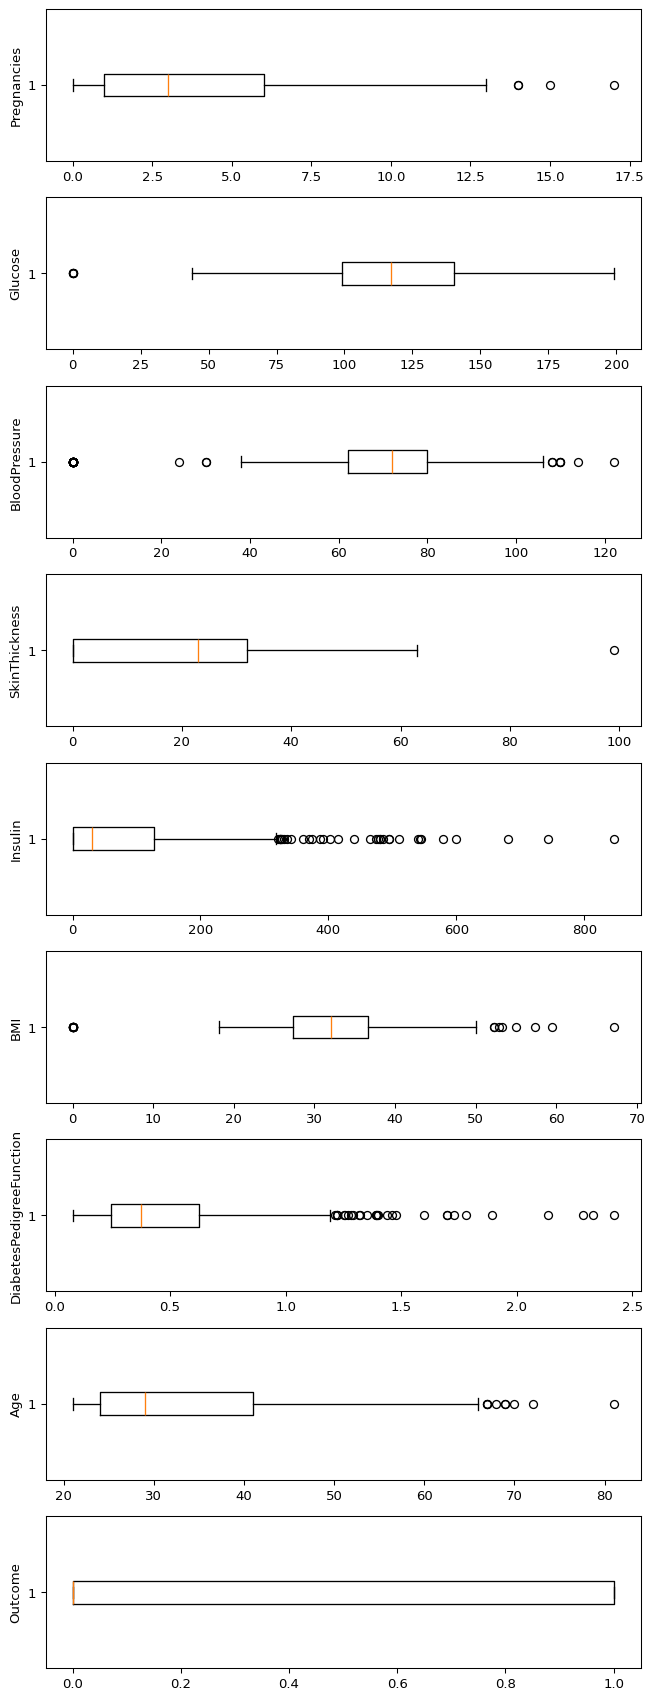

In [4]:
df.describe()

fig, axs = plt.subplots(len(df.columns), 1, figsize=(7, 18), dpi=95)
for i, col in enumerate(df.columns):
    axs[i].boxplot(df[col], vert=False)
    axs[i].set_ylabel(col)
plt.tight_layout()
plt.show()

In [12]:
#Step 4: Remove outliers using the interquartile range method

Iq1, Iq3 = np.percentile(df['Insulin'], [25, 75])
Iiqr = Iq3 - Iq1
Ilower = Iq1 - 1.5 * Iiqr
Iupper = Iq3 + 1.5 * Iiqr
clean_df = df[(df['Insulin'] >= Ilower) & (df['Insulin'] <= Iupper)]


In [ ]:
Pq1, Pq3 = np.percentile(df['Pregnancies'], [25, 75])
Piqr = Pq3 - Pq1
Plower = Pq1 - 1.5 * Piqr
Pupper = Pq3 + 1.5 * Piqr
clean_df = df[(df['Pregnancies'] >= Plower) & (df['Pregnancies'] <= Pupper)]

In [13]:
Gq1, Gq3 = np.percentile(df['Glucose'], [25, 75])
Giqr = Gq3 - Gq1
Glower = Gq1 - 1.5 * Giqr
Gupper = Gq3 + 1.5 * Giqr
clean_df = df[(df['Glucose'] >= Glower) & (df['Glucose'] <= Gupper)]

In [ ]:
Bq1, Bq3 = np.percentile(df['BloodPressure'], [25, 75])
Biqr = Bq3 - Bq1
Blower = Bq1 - 1.5 * Biqr
Bupper = Bq3 + 1.5 * Biqr
clean_df = df[(df['BloodPressure'] >= Blower) & (df['BloodPressure'] <= Bupper)]

In [ ]:
Sq1, Sq3 = np.percentile(df['SkinThickness'], [25, 75])
Siqr = Sq3 - Sq1
Slower = Sq1 - 1.5 * Siqr
Supper = Sq3 + 1.5 * Siqr
clean_df = df[(df['SkinThickness'] >= Slower) & (df['SkinThickness'] <= Supper)]

In [14]:
BMq1, BMq3 = np.percentile(df['BMI'], [25, 75])
BMiqr = BMq3 - BMq1
BMlower = BMq1 - 1.5 * BMiqr
BMupper = BMq3 + 1.5 * BMiqr
clean_df = df[(df['BMI'] >= BMlower) & (df['BMI'] <= BMupper)]

In [15]:
Dq1, Dq3 = np.percentile(df['DiabetesPedigreeFunction'], [25, 75])
Diqr = Dq3 - Dq1
Dlower = Dq1 - 1.5 * Diqr
Dupper = Dq3 + 1.5 * Diqr
clean_df = df[(df['DiabetesPedigreeFunction'] >= Dlower) & (df['DiabetesPedigreeFunction'] <= Dupper)]

In [16]:
Aq1, Aq3 = np.percentile(df['Age'], [25, 75])
Aiqr = Aq3 - Aq1
Alower = Aq1 - 1.5 * Aiqr
Aupper = Aq3 + 1.5 * Aiqr
clean_df = df[(df['Age'] >= Alower) & (df['Age'] <= Aupper)]

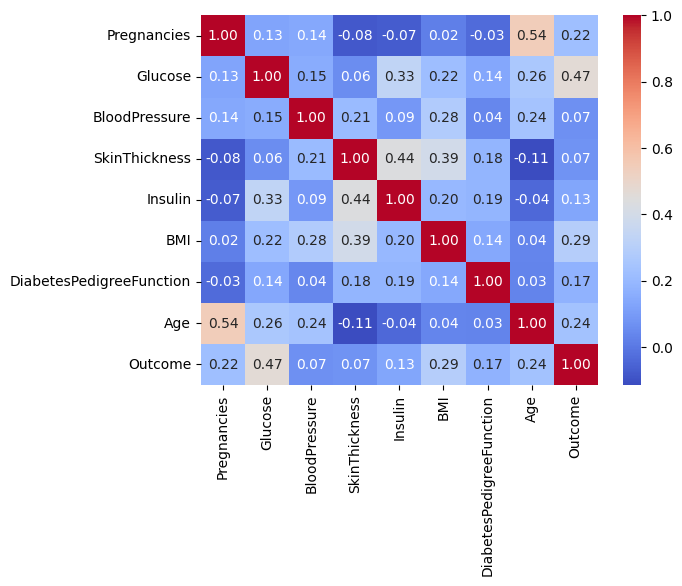

Outcome                     1.000000
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [17]:
corr = df.corr()
plt.Figure(dpi=130)
sns.heatmap(corr, annot = True, fmt='.2f', cmap='coolwarm')
plt.show()

print(corr['Outcome'].sort_values(ascending =False))

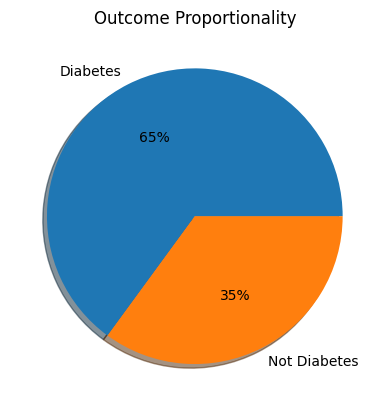

In [ ]:
#Step 6: Visualize target variable distribution

plt.pie(clean_df['Outcome'].value_counts(), #Pie chart to display proportion of each class in the target vairable 'Outcome'
        labels =['Diabetes', 'Not Diabetes'],
        autopct='%.f%%', shadow=True)

plt.title('Outcome Proportionality')
plt.show()

In [ ]:
#step 7: Seperate Feautrees and target variables

X = df.drop(columns=['Outcome']) #Drops the target column from features
y = df['Outcome']

In [ ]:
#Feature SCaling : Normalization and Standardization

#Normalization
scaler = MinMaxScaler() #Rescales features between 0 and 1, good for algorithms like k-NN and neural netwokes
X_normalized = scaler.fit_transform(X)
print(X_normalized[:5])

[[0.35294118 0.74371859 0.59016393 0.35353535 0.         0.50074516
  0.23441503 0.48333333]
 [0.05882353 0.42713568 0.54098361 0.29292929 0.         0.39642325
  0.11656704 0.16666667]
 [0.47058824 0.91959799 0.52459016 0.         0.         0.34724292
  0.25362938 0.18333333]
 [0.05882353 0.44723618 0.54098361 0.23232323 0.11111111 0.41877794
  0.03800171 0.        ]
 [0.         0.68844221 0.32786885 0.35353535 0.19858156 0.64232489
  0.94363792 0.2       ]]


In [21]:
#Standardization:Transforms features to have mean = 0 and standard deviation = 1, useful for normally distributed features

scaler = StandardScaler()
X_standardized = scaler.fit_transform(X)
print(X_standardized[:5])


[[ 0.63994726  0.84832379  0.14964075  0.90726993 -0.69289057  0.20401277
   0.46849198  1.4259954 ]
 [-0.84488505 -1.12339636 -0.16054575  0.53090156 -0.69289057 -0.68442195
  -0.36506078 -0.19067191]
 [ 1.23388019  1.94372388 -0.26394125 -1.28821221 -0.69289057 -1.10325546
   0.60439732 -0.10558415]
 [-0.84488505 -0.99820778 -0.16054575  0.15453319  0.12330164 -0.49404308
  -0.92076261 -1.04154944]
 [-1.14185152  0.5040552  -1.50468724  0.90726993  0.76583594  1.4097456
   5.4849091  -0.0204964 ]]
